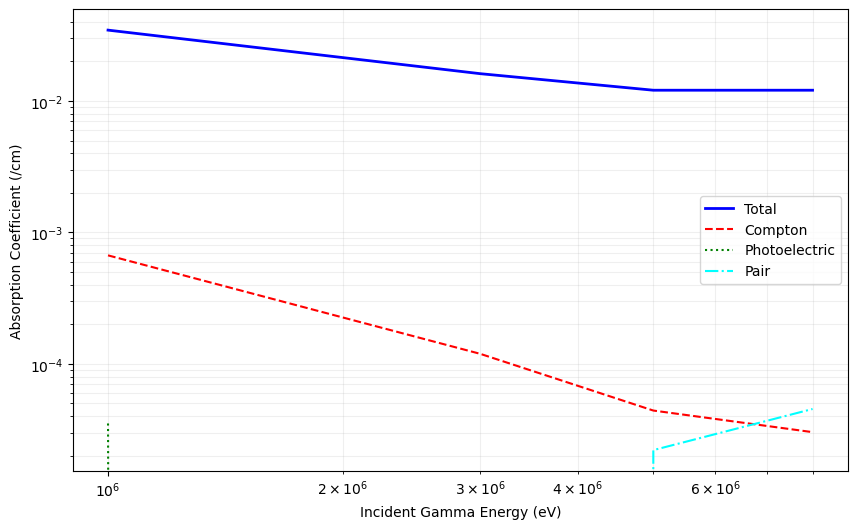

In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# CONFIGURATION
# Update these IDs based on your findings from Step 2
ID_PHOTO = 2012   # Example ID for photoelectric
ID_COMPT = 2013    # Example ID for compton
ID_PAIR  = 2014    # Example ID for pair production

files = {
    1e6: "1MeV_gamma.root",
    3e6: "3MeV_gamma.root",
    5e6: "5MeV_gamma.root",
    8e6: "8MeV_gamma.root"
}
def calculate_mu(file_path, n_incident=500, thickness=1.0):
    with uproot.open(file_path) as f:
        tree = f["t"]
        
        # 1. Get both the Event ID (n) and the Process ID (pro)
        n_array = tree["n"].array(library="np")
        pro_array = tree["pro"].array(library="np")
        
        # Flatten them if they are jagged (common in Geant4)
        n_flat = np.concatenate(n_array) if isinstance(n_array[0], (np.ndarray, list)) else n_array
        pro_flat = np.concatenate(pro_array) if isinstance(pro_array[0], (np.ndarray, list)) else pro_array

        # 2. Count UNIQUE particles that interacted
        unique_interacted_particles = len(np.unique(n_flat))
        
        # 3. Calculate transmission correctly
        n_trans = n_incident - unique_interacted_particles
        
        # Safety Check: prevent log(0)
        if n_trans <= 0:
            print(f"Warning: No particles transmitted in {file_path}. Increase n_incident.")
            return np.nan, np.nan, np.nan, np.nan
            
        mu_tot = -np.log(n_trans / n_incident) / thickness
        
        # 4. Component calculations
        # total_rows is still used for the ratio of process types
        total_rows = len(pro_flat)
        mu_p  = (np.count_nonzero(pro_flat == ID_PHOTO) / total_rows) * mu_tot if total_rows > 0 else 0
        mu_c  = (np.count_nonzero(pro_flat == ID_COMPT) / total_rows) * mu_tot if total_rows > 0 else 0
        mu_pp = (np.count_nonzero(pro_flat == ID_PAIR) / total_rows) * mu_tot if total_rows > 0 else 0
        
        return mu_tot, mu_p, mu_c, mu_pp

# Data Collection
energies = sorted(files.keys())
results = {"tot": [], "p": [], "c": [], "pp": []}

for e in energies:
    mt, mp, mc, mpp = calculate_mu(files[e])
    results["tot"].append(mt)
    results["p"].append(mp)
    results["c"].append(mc)
    results["pp"].append(mpp)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(energies, results["tot"], 'b-', label='Total', lw=2)
plt.plot(energies, results["c"], 'r--', label='Compton')
plt.plot(energies, results["p"], 'g:', label='Photoelectric')
plt.plot(energies, results["pp"], 'cyan', linestyle='-.', label='Pair')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Incident Gamma Energy (eV)')
plt.ylabel('Absorption Coefficient (/cm)')
plt.grid(True, which="both", alpha=0.2)
plt.legend()
plt.show()